# Day 07 — Project: European Soccer

Marcus does recruitment analytics for a Championship club. Six weeks before the January transfer window, his technical director wants two things on his desk: a shortlist of attacking targets worth a scouting trip, and a read on how the leagues they might buy from actually play. The club's data team also feeds a small betting newsletter on the side, so there's a third ask tacked on at the end — is "favorite" actually worth anything?

No new SQL syntax today — everything here is Days 01-04 (filtering, aggregation, JOINs, views, window functions, anti-joins) applied to a real 7-table dataset of European football matches, players, and teams, 2008-2016, run through jupysql's `%%sql` magic from Day 05. See `day07_reading.html` for the full brief and where the dataset comes from.

## Getting connected

In [1]:
%load_ext sql

In [2]:
%sql sqlite:///../Databases/soccer.sqlite --alias soccer

Connecting to 'soccer'

A bare connection string, no SQLAlchemy needed — same Option 2 pattern as every project day since Day 05.

In [3]:
%%sql
SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;

Running query in 'soccer'

name
Country
League
Match
Player
Player_Attributes
Team
Team_Attributes
sqlite_sequence


7 real tables (`sqlite_sequence` is SQLite's own internal bookkeeping, not data). A quick preview of each before Marcus's questions start:

In [4]:
from IPython.display import Markdown, display

tables_result = %sql SELECT name FROM sqlite_master WHERE type='table' AND name != 'sqlite_sequence' ORDER BY name
table_names = tables_result.DataFrame()['name'].tolist()

for table in table_names:
    display(Markdown(f"### {table}"))
    preview = %sql SELECT * FROM {{table}} LIMIT 3
    display(preview)

Running query in 'soccer'

### Country

Running query in 'soccer'

id,name
1,Belgium
1729,England
4769,France


### League

...

Running query in 'soccer'

id,team_api_id,team_fifa_api_id,team_long_name,team_short_name
1,9987,673,KRC Genk,GEN
2,9993,675,Beerschot AC,BAC
3,10000,15005,SV Zulte-Waregem,ZUL


### Team_Attributes

Running query in 'soccer'

id,team_fifa_api_id,team_api_id,date,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,buildUpPlayPositioningClass,chanceCreationPassing,chanceCreationPassingClass,chanceCreationCrossing,chanceCreationCrossingClass,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
1,434,9930,2010-02-22 00:00:00,60,Balanced,None,Little,50,Mixed,Organised,60,Normal,65,Normal,55,Normal,Organised,50,Medium,55,Press,45,Normal,Cover
2,434,9930,2014-09-19 00:00:00,52,Balanced,48,Normal,56,Mixed,Organised,54,Normal,63,Normal,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover
3,434,9930,2015-09-10 00:00:00,47,Balanced,41,Normal,54,Mixed,Organised,54,Normal,63,Normal,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover


---

Two definitions are worth setting up once before answering anything — the `CREATE VIEW` pattern from Day 04, reused across most of the questions below.

`Player_Attributes` and `Team_Attributes` both carry one row per player/team *per rating date* — a player has dozens of historical rows, not one. Every question about a player's or team's *current* profile needs exactly one row per entity: the most recent. `ROW_NUMBER() OVER (PARTITION BY ... ORDER BY date DESC) = 1` — the Day 04 window-function pattern — is the portable way to get it; a plain `GROUP BY` with `MAX(date)` happens to work in SQLite for this specific shape of query (SQLite guarantees the other selected columns come from the max-date row when there's exactly one `MAX()` in play) but that's SQLite-specific behavior, not standard SQL, and it silently breaks the moment a second aggregate gets added — so the window-function version is what's used everywhere in this notebook.

In [5]:
%%sql
DROP VIEW IF EXISTS current_player_ratings;
CREATE VIEW current_player_ratings AS
SELECT * FROM (
    SELECT p.player_name, a.overall_rating, a.preferred_foot, a.finishing,
           a.free_kick_accuracy, a.sprint_speed, a.crossing, a.heading_accuracy,
           ROW_NUMBER() OVER (PARTITION BY a.player_api_id ORDER BY a.date DESC) AS rn
    FROM Player p
    JOIN Player_Attributes a ON p.player_api_id = a.player_api_id
)
WHERE rn = 1;

Running query in 'soccer'

++
||
++
++

In [6]:
%%sql
DROP VIEW IF EXISTS current_team_style;
CREATE VIEW current_team_style AS
SELECT * FROM (
    SELECT t.team_api_id, t.team_long_name, ta.buildUpPlaySpeed, ta.defencePressure,
           ROW_NUMBER() OVER (PARTITION BY ta.team_api_id ORDER BY ta.date DESC) AS rn
    FROM Team t
    JOIN Team_Attributes ta ON t.team_api_id = ta.team_api_id
)
WHERE rn = 1;

Running query in 'soccer'

++
||
++
++

One more view — every team's league, looked up once from `Match` instead of repeating the JOIN chain in every league-level question later on:

In [7]:
%%sql
DROP VIEW IF EXISTS team_league_lookup;
CREATE VIEW team_league_lookup AS
SELECT DISTINCT home_team_api_id AS team_id, league_id
FROM Match;

Running query in 'soccer'

++
||
++
++

Marcus opens with the players — who's actually worth a scouting trip.

### Q1 — Who are the 10 highest-rated players right now?

**Business question:** the baseline — who's already elite, so Marcus knows who's out of the club's price range before he even starts.

In [8]:
%%sql top_rated_result  <<
SELECT player_name, overall_rating
FROM current_player_ratings
ORDER BY overall_rating DESC
LIMIT 10

Running query in 'soccer'

<Axes: title={'center': 'Highest-rated players, current'}, ylabel='player_name'>

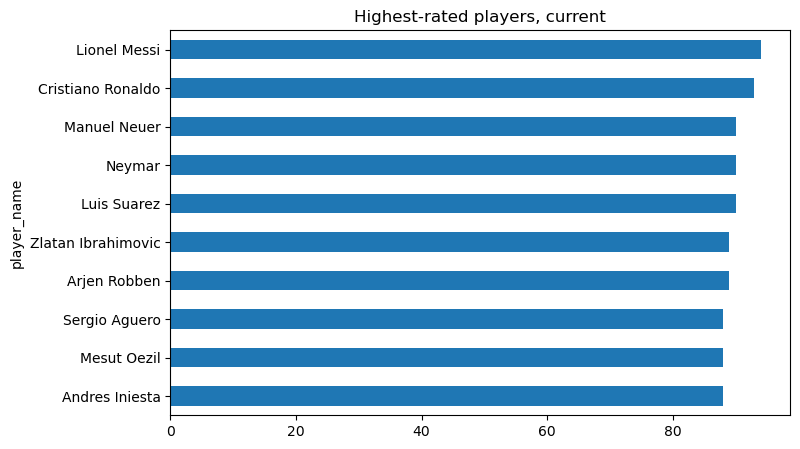

In [9]:
top_rated = top_rated_result.DataFrame()
top_rated.sort_values("overall_rating").plot(
    x="player_name", y="overall_rating", kind="barh", figsize=(8, 5), legend=False,
    title="Highest-rated players, current")

**Insight:** Messi (94) and Ronaldo (93) top the list, well clear of Neymar and Manuel Neuer tied at 90 — exactly the household names you'd expect, which is a good sign the rest of the analysis is sound before trusting it on less familiar names.

### Q2 — Does preferred foot make a measurable difference?

**Business question:** scouting folklore says left-footed players are undervalued specialists — worth checking before it shapes a recommendation.

In [10]:
%%sql
SELECT preferred_foot,
       COUNT(*) AS n,
       ROUND(AVG(overall_rating), 1) AS avg_rating,
       ROUND(AVG(finishing), 1) AS avg_finishing,
       ROUND(AVG(free_kick_accuracy), 1) AS avg_free_kick
FROM current_player_ratings
WHERE preferred_foot IS NOT NULL
GROUP BY preferred_foot;

Running query in 'soccer'

preferred_foot,n,avg_rating,avg_finishing,avg_free_kick
left,2687,68.0,48.0,52.2
right,8373,67.9,48.2,46.9


**Insight:** overall rating is essentially identical (68.0 left vs. 67.9 right) — no general left-foot premium. But free-kick accuracy tells a different story: 52.2 for left-footers vs. 46.9 for right-footers, a real gap that doesn't show up anywhere else. The folklore is half right — it's a specific-skill effect, not an overall one.

### Q3 — Which players have improved the most since their first rating on record?

**Business question:** a breakout-prospect angle — young players still on the way up cost far less than the finished product from Q1.

In [11]:
%%sql improved_result  <<
WITH bounds AS (
    SELECT p.player_name, a.player_api_id,
           FIRST_VALUE(a.overall_rating) OVER (PARTITION BY a.player_api_id ORDER BY a.date ASC) AS first_rating,
           FIRST_VALUE(a.overall_rating) OVER (PARTITION BY a.player_api_id ORDER BY a.date DESC) AS latest_rating,
           ROW_NUMBER() OVER (PARTITION BY a.player_api_id ORDER BY a.date ASC) AS rn
    FROM Player p JOIN Player_Attributes a ON p.player_api_id = a.player_api_id
)
SELECT player_name, first_rating, latest_rating, (latest_rating - first_rating) AS improvement
FROM bounds WHERE rn = 1
ORDER BY improvement DESC
LIMIT 10

Running query in 'soccer'

<Axes: title={'center': 'Biggest rating improvement, first record to latest'}, ylabel='player_name'>

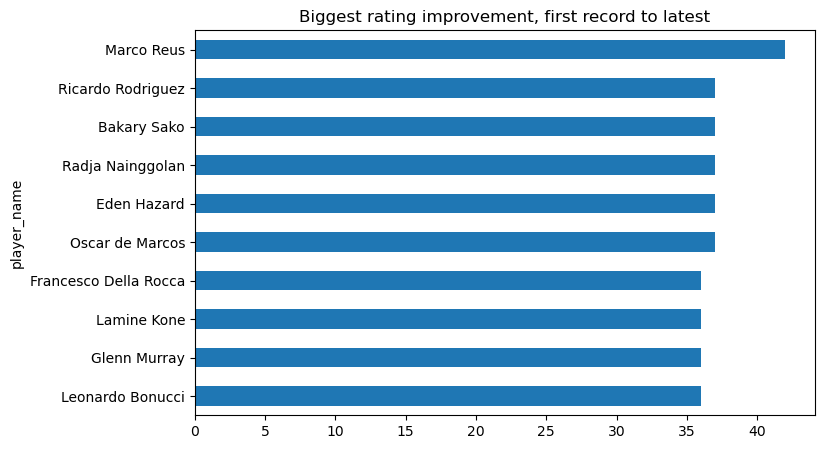

In [12]:
improved = improved_result.DataFrame()
improved.sort_values("improvement").plot(
    x="player_name", y="improvement", kind="barh", figsize=(8, 5), legend=False,
    title="Biggest rating improvement, first record to latest")

**Insight:** Marco Reus tops the list, +42 (44 → 86) — matches his real breakout in the early 2010s. `FIRST_VALUE() OVER (... ORDER BY date ASC)` and `... ORDER BY date DESC)` in the same CTE pull both ends of each player's career in one pass, no self-join needed.

### Q4 — Who are the top 10 finishers?

**Business question:** the club needs a striker — pure finishing ability, regardless of overall rating or price tag.

In [13]:
%%sql top_finishers_result  <<
SELECT player_name, finishing
FROM current_player_ratings
ORDER BY finishing DESC
LIMIT 10

Running query in 'soccer'

<Axes: title={'center': 'Highest finishing rating, current'}, ylabel='player_name'>

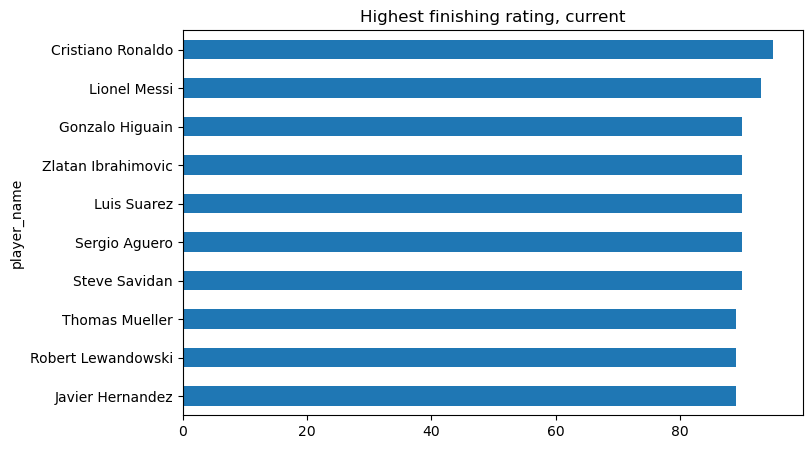

In [14]:
top_finishers = top_finishers_result.DataFrame()
top_finishers.sort_values("finishing").plot(
    x="player_name", y="finishing", kind="barh", figsize=(8, 5), legend=False,
    title="Highest finishing rating, current")

**Insight:** Ronaldo (95) edges Messi (93) here — the one attribute where Ronaldo actually leads the head-to-head, worth a footnote for the report even though Messi topped the overall list in Q1.

### Q5 — Who are the 10 fastest players?

**Business question:** a counter-attacking system needs raw pace over the top — a different shortlist than the finishers above.

In [15]:
%%sql top_pace_result  <<
SELECT player_name, sprint_speed
FROM current_player_ratings
ORDER BY sprint_speed DESC
LIMIT 10

Running query in 'soccer'

<Axes: title={'center': 'Highest sprint speed, current'}, ylabel='player_name'>

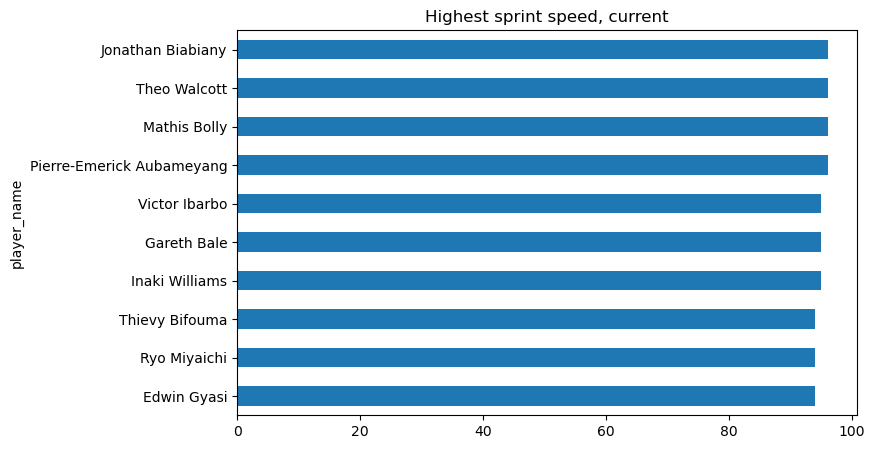

In [16]:
top_pace = top_pace_result.DataFrame()
top_pace.sort_values("sprint_speed").plot(
    x="player_name", y="sprint_speed", kind="barh", figsize=(8, 5), legend=False,
    title="Highest sprint speed, current")

**Insight:** Pierre-Emerick Aubameyang leads at 96 — barely edging Ronaldo (93) and Messi (90), who both show up here too despite this being a completely different attribute than Q1 or Q4. Elite players tend to be elite on more than one axis.

### Q6 — Which players combine elite finishing *and* elite pace?

**Business question:** the actual shortlist Marcus takes to the director — not the best at one thing, the best at the specific combination the system needs.

In [17]:
%%sql
SELECT player_name, finishing, sprint_speed
FROM current_player_ratings
WHERE finishing >= 85 AND sprint_speed >= 85
ORDER BY finishing DESC
LIMIT 10;

Running query in 'soccer'

player_name,finishing,sprint_speed
Cristiano Ronaldo,95,93
Lionel Messi,93,90
Sergio Aguero,90,86
Javier Hernandez,89,85
Neymar,88,90
Carlos Tevez,88,87
Pierre-Emerick Aubameyang,88,96
Antoine Griezmann,87,86
Paulo Dybala,87,85
Jackson Martinez,86,85


**Insight:** Ronaldo, Messi, Aguero, and Neymar all clear both bars — the shortlist is short (10 players worldwide meet it), which is exactly the point: multi-criteria filtering on a view is one `WHERE` clause, not a rebuilt query, because the view already did the hard part.

With a shortlist in hand, Marcus turns to team-level scouting — style worth copying, and clubs actually worth studying.

### Q7 — Which teams play with the fastest build-up speed?

**Business question:** if the director wants a faster, more direct style, these are the clubs playing it already.

In [18]:
%%sql top_speed_teams_result  <<
SELECT team_long_name, buildUpPlaySpeed
FROM current_team_style
ORDER BY buildUpPlaySpeed DESC
LIMIT 10

Running query in 'soccer'

<Axes: title={'center': 'Fastest build-up play, by team'}, ylabel='team_long_name'>

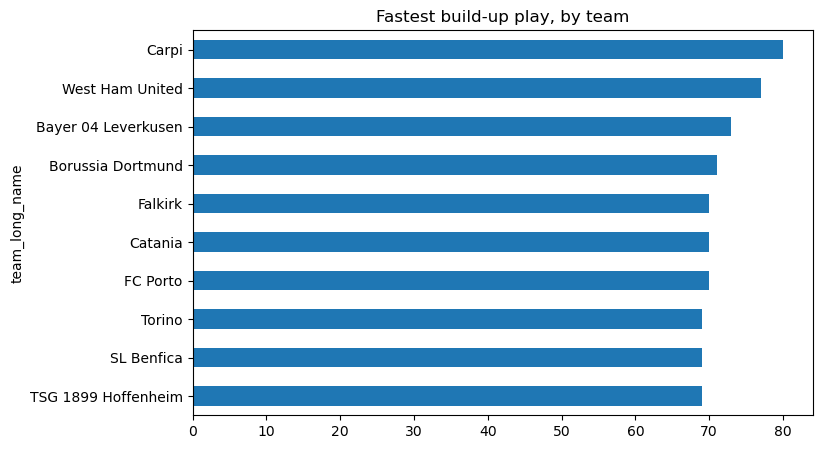

In [19]:
top_speed_teams = top_speed_teams_result.DataFrame()
top_speed_teams.sort_values("buildUpPlaySpeed").plot(
    x="team_long_name", y="buildUpPlaySpeed", kind="barh", figsize=(8, 5), legend=False,
    title="Fastest build-up play, by team")

**Insight:** Carpi (an Italian club promoted to Serie A for a single 2015-16 season) tops the list at 80 — a reminder that a style rating alone doesn't say anything about whether that style actually won matches (Q12 checks that directly).

### Q8 — Which teams win the highest share of their matches?

**Business question:** the clubs Marcus should study for what winning football actually looks like in this data.

In [20]:
%%sql win_pct_result  <<
WITH results AS (
    SELECT home_team_api_id AS team_id, CASE WHEN home_team_goal > away_team_goal THEN 1 ELSE 0 END AS win
    FROM Match
    UNION ALL
    SELECT away_team_api_id, CASE WHEN away_team_goal > home_team_goal THEN 1 ELSE 0 END
    FROM Match
)
SELECT t.team_long_name, COUNT(*) AS matches, ROUND(SUM(win) * 100.0 / COUNT(*), 1) AS win_pct
FROM results r
JOIN Team t ON r.team_id = t.team_api_id
GROUP BY t.team_long_name
HAVING COUNT(*) >= 100
ORDER BY win_pct DESC
LIMIT 10

Running query in 'soccer'

<Axes: title={'center': 'Win rate, teams with 100+ matches in the dataset'}, ylabel='team_long_name'>

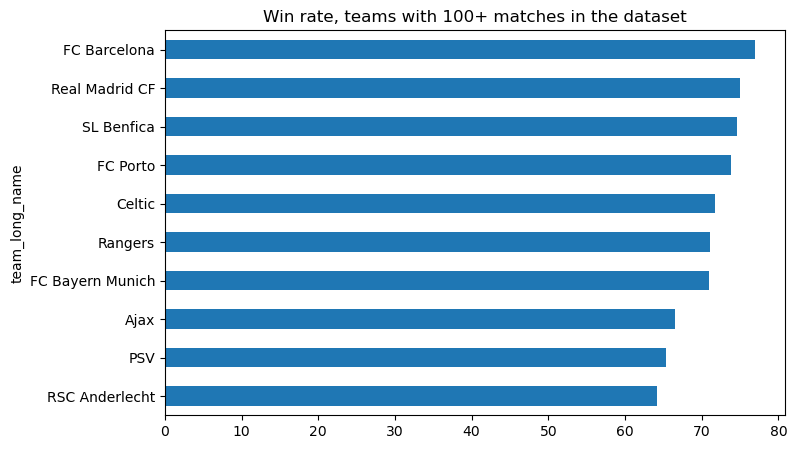

In [21]:
win_pct = win_pct_result.DataFrame()
win_pct.sort_values("win_pct").plot(
    x="team_long_name", y="win_pct", kind="barh", figsize=(8, 5), legend=False,
    title="Win rate, teams with 100+ matches in the dataset")

**Insight:** FC Barcelona (77.0%) and Real Madrid (75.0%) lead, well clear of SL Benfica (74.6%) and FC Porto (73.8%) — the `UNION ALL` combining a team's home and away results into one column before aggregating is the same shape as `game LEFT JOIN team_details` in Day 06's Q15, just unioning instead of joining.

### Q9 — What are the biggest win margins on record?

**Business question:** a trivia callout for the newsletter — always a reader favorite.

In [22]:
%%sql
SELECT m.date, ht.team_long_name AS home, at.team_long_name AS away,
       m.home_team_goal, m.away_team_goal, (m.home_team_goal - m.away_team_goal) AS margin
FROM Match m
JOIN Team ht ON m.home_team_api_id = ht.team_api_id
JOIN Team at ON m.away_team_api_id = at.team_api_id
ORDER BY ABS(m.home_team_goal - m.away_team_goal) DESC
LIMIT 5;

Running query in 'soccer'

date,home,away,home_team_goal,away_team_goal,margin
2010-10-24 00:00:00,PSV,Feyenoord,10,0,10
2016-03-13 00:00:00,ES Troyes AC,Paris Saint-Germain,0,9,-9
2010-11-06 00:00:00,Celtic,Aberdeen,9,0,9
2009-11-22 00:00:00,Tottenham Hotspur,Wigan Athletic,9,1,8
2010-05-09 00:00:00,Chelsea,Wigan Athletic,8,0,8


**Insight:** PSV 10-0 over Feyenoord (Oct 2010) tops the list — a 10-goal margin, ahead of Paris Saint-Germain's 9-0 away win at ES Troyes AC. Both ends of a blowout show up once `ABS()` is applied to the margin, not just the biggest home wins.

### Q10 — Which teams score the most goals per match?

**Business question:** the attacking benchmark — how far off the best is the club Marcus works for?

In [23]:
%%sql goals_scored_result  <<
WITH gf AS (
  SELECT home_team_api_id AS team_id, home_team_goal AS goals FROM Match
  UNION ALL
  SELECT away_team_api_id, away_team_goal FROM Match
)
SELECT t.team_long_name, COUNT(*) AS matches, ROUND(AVG(goals), 2) AS avg_goals_scored
FROM gf
JOIN Team t ON gf.team_id = t.team_api_id
GROUP BY t.team_long_name
HAVING COUNT(*) >= 100
ORDER BY avg_goals_scored DESC
LIMIT 10

Running query in 'soccer'

<Axes: title={'center': 'Goals scored per match, teams with 100+ matches'}, ylabel='team_long_name'>

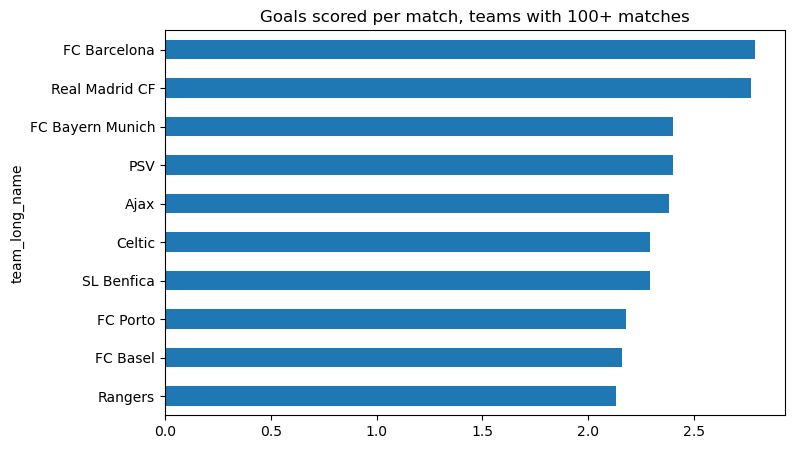

In [24]:
goals_scored = goals_scored_result.DataFrame()
goals_scored.sort_values("avg_goals_scored").plot(
    x="team_long_name", y="avg_goals_scored", kind="barh", figsize=(8, 5), legend=False,
    title="Goals scored per match, teams with 100+ matches")

**Insight:** FC Barcelona (2.79) and Real Madrid (2.77) lead again — the same two clubs from Q8's win-rate list, which makes sense, but it's worth confirming rather than assuming the two rankings line up.

### Q11 — Which teams concede the fewest goals per match?

**Business question:** the defensive counterpart to Q10 — attack wins headlines, but Marcus's club needs a realistic target, and defense might be the more copyable trait.

In [25]:
%%sql goals_conceded_result  <<
WITH ga AS (
  SELECT home_team_api_id AS team_id, away_team_goal AS goals FROM Match
  UNION ALL
  SELECT away_team_api_id, home_team_goal FROM Match
)
SELECT t.team_long_name, COUNT(*) AS matches, ROUND(AVG(goals), 2) AS avg_goals_conceded
FROM ga
JOIN Team t ON ga.team_id = t.team_api_id
GROUP BY t.team_long_name
HAVING COUNT(*) >= 100
ORDER BY avg_goals_conceded ASC
LIMIT 10

Running query in 'soccer'

<Axes: title={'center': 'Goals conceded per match, teams with 100+ matches (lower is better)'}, ylabel='team_long_name'>

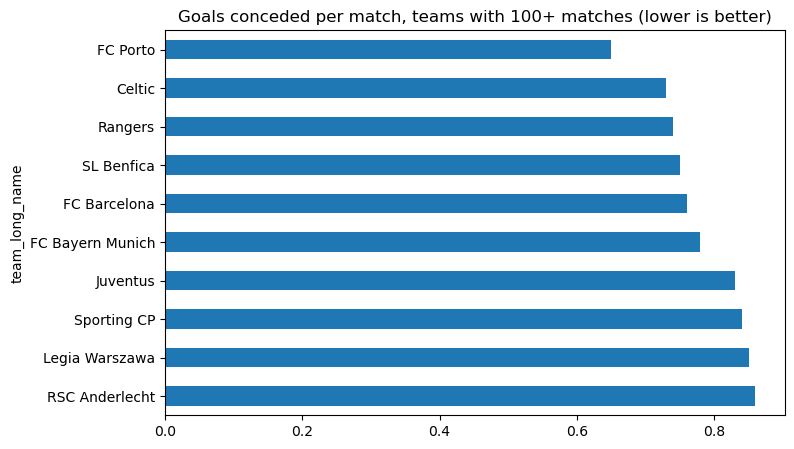

In [26]:
goals_conceded = goals_conceded_result.DataFrame()
goals_conceded.sort_values("avg_goals_conceded", ascending=False).plot(
    x="team_long_name", y="avg_goals_conceded", kind="barh", figsize=(8, 5), legend=False,
    title="Goals conceded per match, teams with 100+ matches (lower is better)")

**Insight:** FC Porto (0.65) has the tightest defense on record, ahead of Celtic (0.73) and Rangers (0.74) — neither Barcelona nor Real Madrid crack the top 10 here, so the attacking benchmark from Q10 and the defensive one aren't the same clubs.

### Q12 — Does a faster build-up style actually mean more goals scored?

**Business question:** before recommending Marcus's club copy Q7's fast-tempo teams, check whether tempo actually predicts scoring, or just looks good on a stat sheet.

In [27]:
%%sql style_vs_goals_result  <<
WITH gf AS (
  SELECT home_team_api_id AS team_id, home_team_goal AS goals FROM Match
  UNION ALL
  SELECT away_team_api_id, away_team_goal FROM Match
),
team_goals AS (
  SELECT team_id, AVG(goals) AS avg_goals FROM gf GROUP BY team_id HAVING COUNT(*) >= 50
)
SELECT cts.buildUpPlaySpeed, tg.avg_goals
FROM current_team_style cts
JOIN team_goals tg ON cts.team_api_id = tg.team_id

Running query in 'soccer'

correlation: 0.034


<Axes: title={'center': 'Build-up speed vs. goals scored per match, 247 teams'}, xlabel='buildUpPlaySpeed', ylabel='avg_goals'>

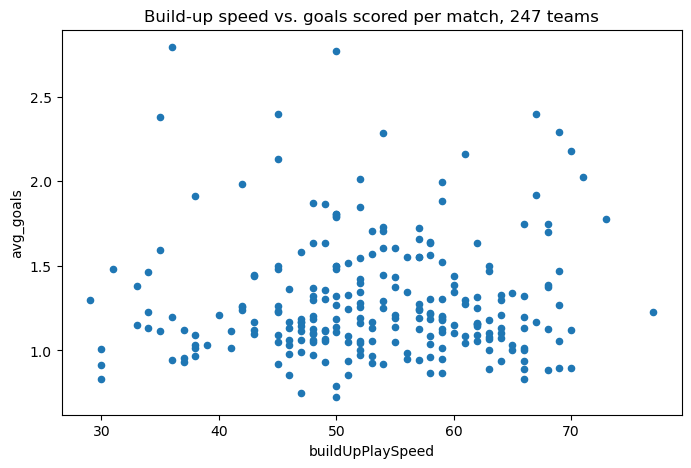

In [28]:
style_vs_goals = style_vs_goals_result.DataFrame()
print("correlation:", round(style_vs_goals["buildUpPlaySpeed"].corr(style_vs_goals["avg_goals"]), 3))
style_vs_goals.plot(kind="scatter", x="buildUpPlaySpeed", y="avg_goals", figsize=(8, 5),
                     title="Build-up speed vs. goals scored per match, 247 teams")

**Insight:** essentially no relationship — a correlation of 0.03, as close to zero as real data gets. Q7's fastest teams (Carpi, West Ham) aren't the same clubs as Q10's top scorers (Barcelona, Real Madrid). The lesson for the report: don't recommend copying a style stat that isn't actually tied to the outcome the club cares about — finishing quality (Q4), not tempo, is what separates the top scorers.

Before recommending a league to scout in, Marcus wants to understand the leagues themselves.

### Q13 — How much does home advantage matter, by league?

**Business question:** if the club is scouting abroad, away form in that league is a real signal — but only if home advantage there is as strong as it is domestically.

In [29]:
%%sql home_win_by_league_result  <<
SELECT l.name AS league,
       ROUND(SUM(CASE WHEN m.home_team_goal > m.away_team_goal THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS home_win_pct,
       COUNT(*) AS matches
FROM Match m
JOIN League l ON m.league_id = l.id
GROUP BY l.name
ORDER BY home_win_pct DESC

Running query in 'soccer'

<Axes: title={'center': 'Home win rate by league'}, ylabel='league'>

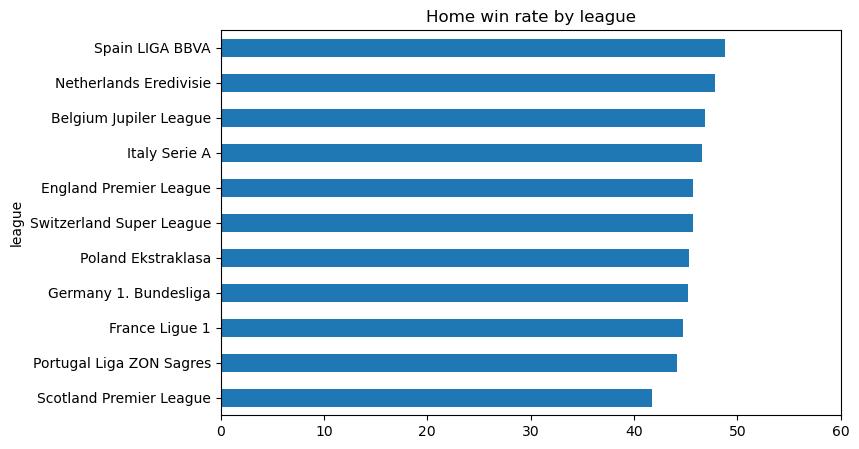

In [30]:
home_win_by_league = home_win_by_league_result.DataFrame()
home_win_by_league.sort_values("home_win_pct").plot(
    x="league", y="home_win_pct", kind="barh", figsize=(8, 5), legend=False,
    title="Home win rate by league", xlim=(0, 60))

**Insight:** Spain's home win rate (48.8%) is the highest of the 11 leagues, Scotland's (41.7%) the lowest — a 7-point spread. Worth flagging in the report: "strong away form" means something different depending on which league a target currently plays in.

### Q14 — Which league sees the most goals per match?

**Business question:** a "most entertaining league" ranking for the newsletter side of the ask.

In [31]:
%%sql goals_by_league_result  <<
SELECT l.name AS league, ROUND(AVG(m.home_team_goal + m.away_team_goal), 2) AS avg_goals
FROM Match m
JOIN League l ON m.league_id = l.id
GROUP BY l.name
ORDER BY avg_goals DESC

Running query in 'soccer'

<Axes: title={'center': 'Average goals per match, by league'}, ylabel='league'>

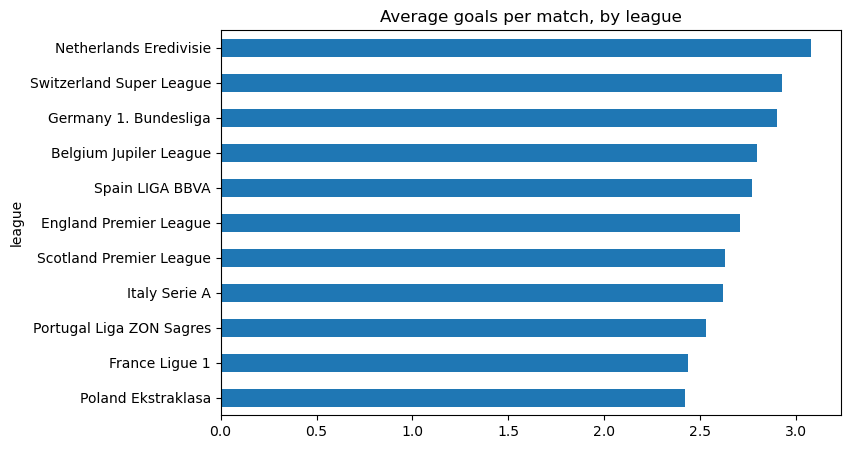

In [32]:
goals_by_league = goals_by_league_result.DataFrame()
goals_by_league.sort_values("avg_goals").plot(
    x="league", y="avg_goals", kind="barh", figsize=(8, 5), legend=False,
    title="Average goals per match, by league")

**Insight:** the Netherlands' Eredivisie averages the most goals per match of the 11 leagues — consistent with its attacking, high-tempo reputation — while the tighter, more defensive leagues cluster lower.

### Q15 — Has scoring changed across the eight seasons in the dataset?

**Business question:** a trend line for the newsletter — is the modern game more attacking than it was in 2008?

In [33]:
%%sql goals_by_season_result  <<
SELECT season, ROUND(AVG(home_team_goal + away_team_goal), 2) AS avg_goals
FROM Match
GROUP BY season
ORDER BY season

Running query in 'soccer'

<Axes: title={'center': 'Average goals per match, by season'}, xlabel='season'>

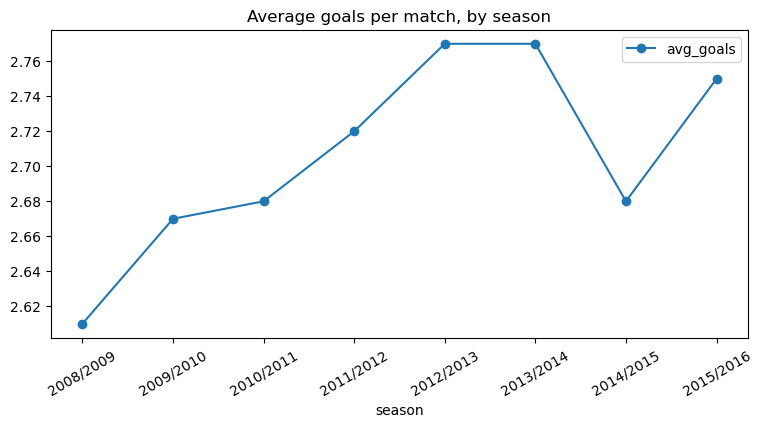

In [34]:
goals_by_season = goals_by_season_result.DataFrame()
goals_by_season.plot(x="season", y="avg_goals", kind="line", marker="o", figsize=(9, 4),
                      title="Average goals per match, by season", rot=30)

**Insight:** a mild, steady climb — 2.61 goals/match in 2008/2009 up to 2.75-2.77 by the mid-2010s. Real, but modest; nothing close to the dramatic swing the "football is more attacking than ever" take usually implies.

### Q16 — How does average playing style compare across leagues?

**Business question:** the closing league-level fact for the director — does league identity show up in the data, or is style just a club-by-club thing?

In [35]:
%%sql style_by_league_result  <<
SELECT l.name AS league,
       ROUND(AVG(cts.buildUpPlaySpeed), 1) AS avg_speed,
       ROUND(AVG(cts.defencePressure), 1) AS avg_pressure,
       COUNT(*) AS teams
FROM current_team_style cts
JOIN team_league_lookup tl ON cts.team_api_id = tl.team_id
JOIN League l ON tl.league_id = l.id
GROUP BY l.name
ORDER BY avg_speed DESC

Running query in 'soccer'

<Axes: title={'center': 'Average team style by league'}, xlabel='league'>

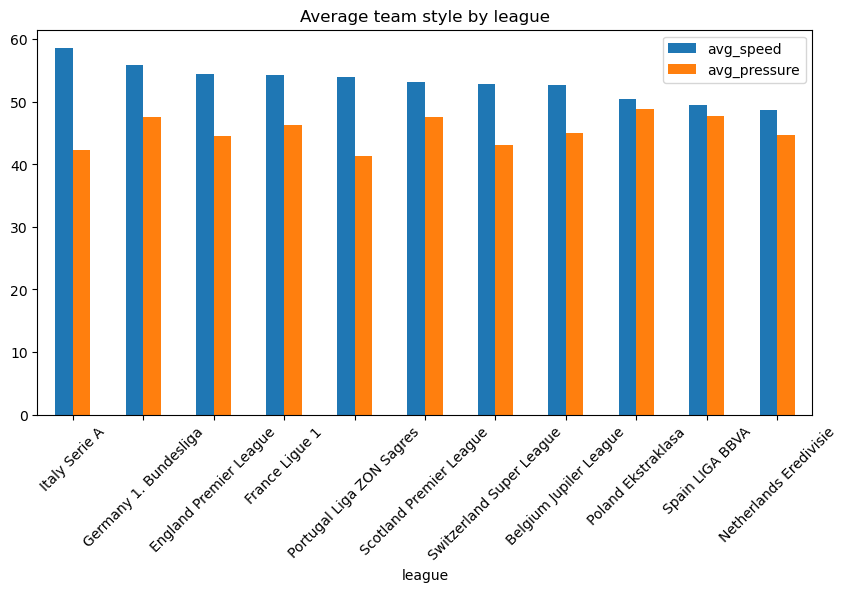

In [36]:
style_by_league = style_by_league_result.DataFrame()
style_by_league.plot(x="league", y=["avg_speed", "avg_pressure"], kind="bar", figsize=(10, 5),
                      title="Average team style by league", rot=45)

**Insight:** Italy's Serie A has the fastest average build-up (58.6) but middling pressure, while Germany's Bundesliga pairs slightly slower build-up (55.8) with the highest defensive pressure (47.6) of the top leagues — a real "gegenpressing" signature showing up directly in the data. This is the four-table JOIN chain (`current_team_style` → `team_league_lookup` → `League`) the two views from earlier were built to make painless.

The newsletter question, last.

### Q17 — Overall, how often do matches end in a home win, draw, or away win?

**Business question:** the newsletter's baseline stat, before checking whether the betting market actually beats it.

In [37]:
%%sql outcome_split_result  <<
SELECT
  ROUND(SUM(CASE WHEN home_team_goal > away_team_goal THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS home_win_pct,
  ROUND(SUM(CASE WHEN home_team_goal = away_team_goal THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS draw_pct,
  ROUND(SUM(CASE WHEN home_team_goal < away_team_goal THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS away_win_pct
FROM Match

Running query in 'soccer'

<Axes: title={'center': 'Match outcome split, all leagues'}>

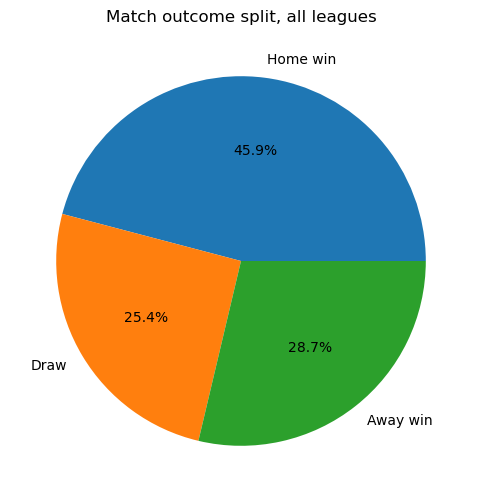

In [38]:
outcome_split = outcome_split_result.DataFrame().iloc[0]
labels = ["Home win", "Draw", "Away win"]
import pandas as pd
pd.Series(outcome_split.values, index=labels).plot(
    kind="pie", autopct="%1.1f%%", ylabel="", figsize=(6, 6), title="Match outcome split, all leagues")

**Insight:** home win 45.9%, draw 25.4%, away win 28.7% — home advantage is real and sizeable (matches Q13's league-by-league breakdown), and a draw is nearly as likely as an away win.

### Q18 — How often does the betting favorite actually win?

**Business question:** the newsletter's actual question — is "favorite" a meaningful label, or closer to a coin flip once you account for home advantage?

In [39]:
%%sql favorite_accuracy_result  <<
SELECT
  SUM(CASE WHEN B365H < B365D AND B365H < B365A AND home_team_goal > away_team_goal THEN 1 ELSE 0 END) AS home_fav_correct,
  SUM(CASE WHEN B365H < B365D AND B365H < B365A THEN 1 ELSE 0 END) AS home_fav_total,
  SUM(CASE WHEN B365A < B365D AND B365A < B365H AND away_team_goal > home_team_goal THEN 1 ELSE 0 END) AS away_fav_correct,
  SUM(CASE WHEN B365A < B365D AND B365A < B365H THEN 1 ELSE 0 END) AS away_fav_total
FROM Match
WHERE B365H IS NOT NULL AND B365D IS NOT NULL AND B365A IS NOT NULL

Running query in 'soccer'

Home favorite    54.5
Away favorite    50.7
dtype: float64

<Axes: title={'center': 'How often the Bet365 favorite actually wins'}>

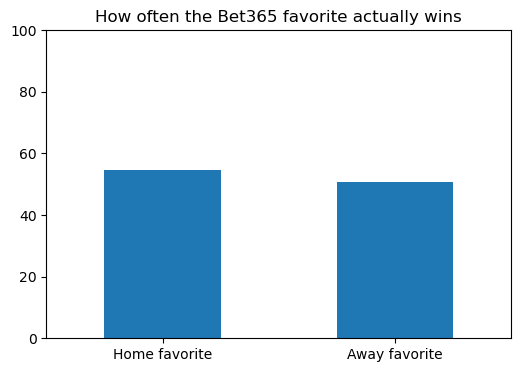

In [40]:
fa = favorite_accuracy_result.DataFrame().iloc[0]
favorite_pct = pd.Series({
    "Home favorite": round(fa["home_fav_correct"] * 100.0 / fa["home_fav_total"], 1),
    "Away favorite": round(fa["away_fav_correct"] * 100.0 / fa["away_fav_total"], 1),
})
display(favorite_pct)
favorite_pct.plot(kind="bar", figsize=(6, 4), legend=False, ylim=(0, 100), rot=0,
                   title="How often the Bet365 favorite actually wins")

**Insight:** a home favorite wins 54.5% of the time it's tagged favorite; an away favorite wins only 50.7% — barely better than a coin flip, and only modestly above Q17's baseline 45.9%/28.7% win rates. The honest answer for the newsletter: bookmaker favorites add real but small predictive value over just always picking the home team — "favorite" is not a safe bet.

### Q19 — What are the biggest upsets on record?

**Business question:** the newsletter's closing trivia hook — heavy favorites that lost outright.

In [41]:
%%sql
SELECT m.date, ht.team_long_name AS home, at.team_long_name AS away,
       m.home_team_goal, m.away_team_goal, m.B365H, m.B365A
FROM Match m
JOIN Team ht ON m.home_team_api_id = ht.team_api_id
JOIN Team at ON m.away_team_api_id = at.team_api_id
WHERE m.B365H IS NOT NULL AND m.B365A IS NOT NULL
  AND m.B365H <= 1.5 AND m.away_team_goal > m.home_team_goal
ORDER BY m.B365H ASC
LIMIT 5;

Running query in 'soccer'

date,home,away,home_team_goal,away_team_goal,B365H,B365A
2010-09-11 00:00:00,FC Barcelona,Hércules Club de Fútbol,0,2,1.06,34
2016-04-04 00:00:00,FC Porto,Tondela,0,1,1.1,23
2015-02-21 00:00:00,FC Barcelona,Málaga CF,0,1,1.11,21
2011-12-31 00:00:00,Manchester United,Blackburn Rovers,2,3,1.13,26
2016-03-02 00:00:00,FC Bayern Munich,1. FSV Mainz 05,1,2,1.13,21


**Insight:** FC Barcelona, at 1.06 odds to beat Hércules at home, lost 0-2 (Sep 2010) — the single biggest upset by odds in the dataset. Even the tightest favorites, the ones the market is most confident about, lose outright often enough to matter.

One more thing, before Marcus signs off — a data-coverage caveat worth flagging to the director.

### Q20 — How many teams in this dataset have no playing-style profile at all?

**Business question:** if the director asks about a smaller club by name, Marcus needs to know upfront whether the data can even answer.

In [42]:
%%sql
SELECT COUNT(*) AS teams_without_style_data
FROM Team t
LEFT JOIN Team_Attributes ta ON t.team_api_id = ta.team_api_id
WHERE ta.id IS NULL;

Running query in 'soccer'

teams_without_style_data
11


In [43]:
%%sql
SELECT t.team_long_name
FROM Team t
LEFT JOIN Team_Attributes ta ON t.team_api_id = ta.team_api_id
WHERE ta.id IS NULL
ORDER BY t.team_long_name
LIMIT 10;

Running query in 'soccer'

team_long_name
Amadora
FC Volendam
FCV Dender EH
Feirense
Lugano
Portimonense
Termalica Bruk-Bet Nieciecza
Tondela
Trofense
Tubize


**Insight:** 11 of 299 teams — smaller clubs like FCV Dender EH and Tubize — have zero `Team_Attributes` rows, so every question from Q7 onward that used `current_team_style` silently excludes them. The same anti-join shape as Day 06's closing question (`LEFT JOIN ... WHERE <right-side key> IS NULL`), used here for a data-coverage check instead of a human-interest story: know what your views can't see before someone asks about a team they can't.